In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib 


In [21]:
data = pd.read_csv("MOVIESPREDICTIONS.csv", encoding='latin1')
print("Shape:", data.shape)
print("Columns:", data.columns.tolist())


Shape: (15509, 10)
Columns: ['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']


In [ ]:

for col in ['Duration', 'Votes', 'Year']:
    data[col] = data[col].astype(str).str.replace(',', '', regex=False)
    data[col] = data[col].str.extract(r'(\d+)')  
    data[col] = pd.to_numeric(data[col], errors='coerce')


In [ ]:

data = data.dropna(subset=['Rating'])


for col in ['Duration', 'Votes', 'Year']:
    data[col] = data[col].fillna(data[col].median())


for col in ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']:
    data[col] = data[col].fillna('Unknown')


In [24]:
le = LabelEncoder()
for col in ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']:
    data[col] = le.fit_transform(data[col])


In [ ]:

X = data.drop(columns=['Rating', 'Name'])
y = data['Rating']


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [27]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)


,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)


Model Performance:
MAE: 0.8313885732323232
RMSE: 1.1004509206198985
R² Score: 0.3486295382647464


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14260\2414559573.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')


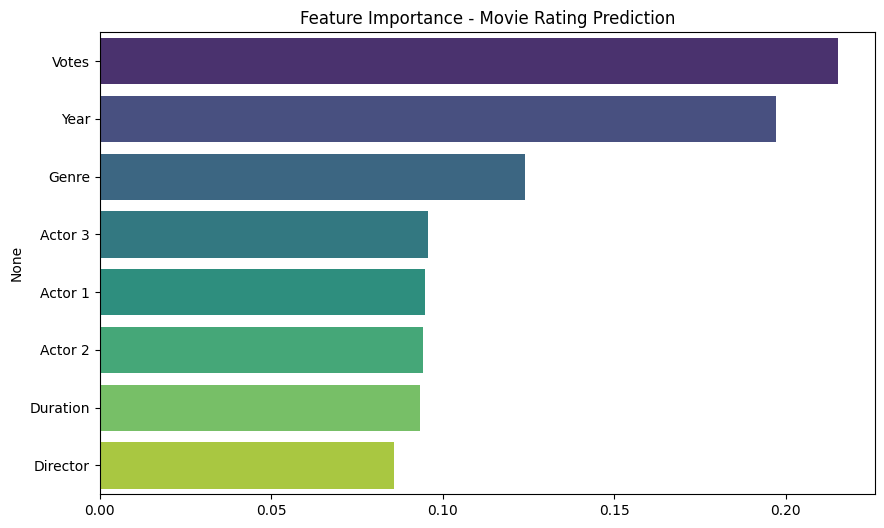

In [29]:
plt.figure(figsize=(10,6))
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title("Feature Importance - Movie Rating Prediction")
plt.show()


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14260\2414559573.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')


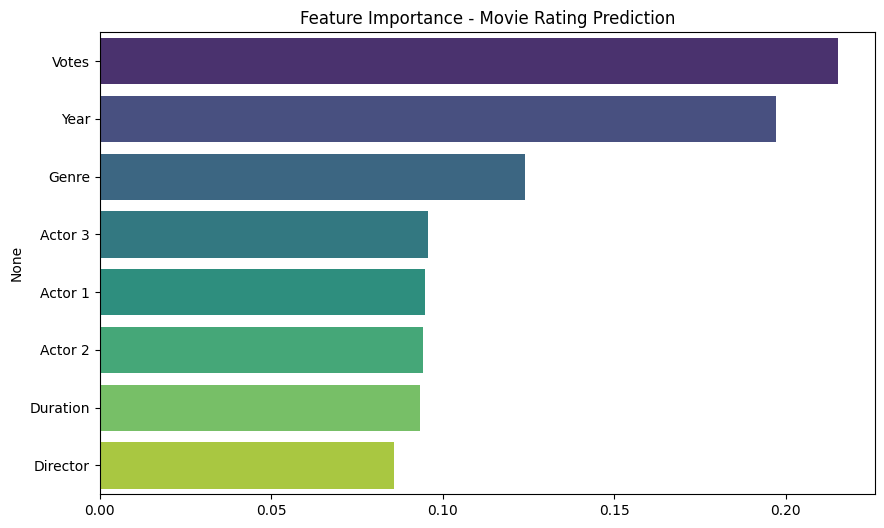

In [30]:
plt.figure(figsize=(10,6))
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title("Feature Importance - Movie Rating Prediction")
plt.show()
